# Tanzania Climate Analysis: Visualizations & COP32 Relevance
**Data source:** NASA POWER (Prediction of Worldwide Energy Resources)

**Objective:** Profile temperature, precipitation, and humidity patterns in Tanzania to inform COP32 policy recommendations.

**Data Loading & Initial Exploration:**:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/tanzania.csv')

**Missing values report:**

In [ ]:
print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)

missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent.round(2)
})

print(missing_report[missing_report['Missing Count'] > 0])

if missing_report[missing_report['Missing Count'] > 0].empty:
    print("\n✅ No missing values found!")

MISSING VALUES REPORT
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

✅ No missing values found!


**Distribution overview:**

In [ ]:
print("\n" + "=" * 50)
print("DISTRIBUTION OVERVIEW")
print("=" * 50)

key_vars = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
print(df[key_vars].describe().round(2))


DISTRIBUTION OVERVIEW
           T2M  T2M_MAX  T2M_MIN  PRECTOTCORR     RH2M
count  4108.00  4108.00  4108.00      4108.00  4108.00
mean     26.80    29.16    25.04         3.74    77.13
std       1.33     1.37     1.54         8.00     5.07
min      22.68    25.41    20.03         0.00    60.06
25%      25.67    28.09    23.71         0.11    73.17
50%      26.99    29.08    25.38         0.64    76.59
75%      27.90    30.17    26.31         3.79    81.10
max      29.97    33.93    28.01       122.65    91.10


In [4]:
df = df.replace(-999, np.nan)
df['Country'] = 'Tanzania'
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month

print(f"Tanzania data loaded: {df.shape[0]} rows")
df.head()

Tanzania data loaded: 4108 rows


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [5]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
print("\nOutliers (|Z| > 3):")
for col in weather_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (abs(z_scores) > 3).sum()
    print(f"{col}: {outliers}")



Outliers (|Z| > 3):
T2M: 1
T2M_MAX: 2
T2M_MIN: 4
PRECTOTCORR: 81
RH2M: 2
WS2M: 8
WS2M_MAX: 4


**Average Temperature by Month:**

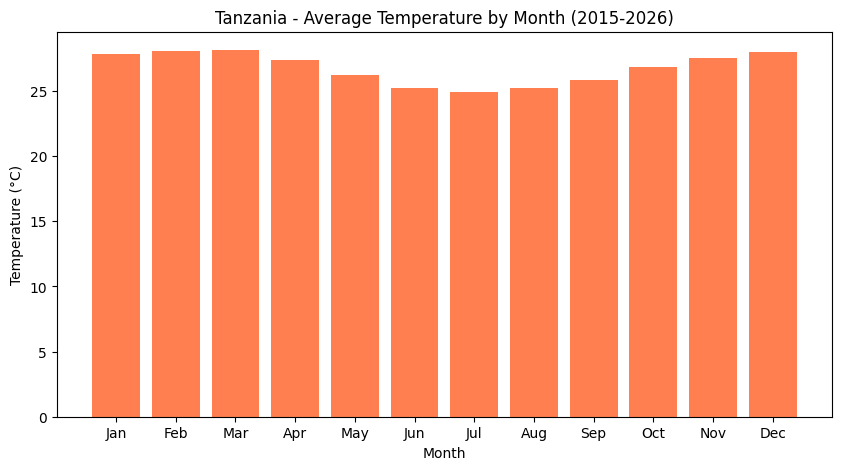

Warmest month: 3 (28.2°C)
Coolest month: 7 (24.9°C)


In [6]:
monthly_avg = df.groupby('Month')['T2M'].mean()
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='coral')
plt.title('Tanzania - Average Temperature by Month (2015-2026)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()
print(f"Warmest month: {monthly_avg.idxmax()} ({monthly_avg.max():.1f}°C)")
print(f"Coolest month: {monthly_avg.idxmin()} ({monthly_avg.min():.1f}°C)")

### Temperature by Month (Bar Chart)
**What it shows:** Average monthly temperatures (Jan-Dec)

**Key findings:**
- Warmest months: January-February (27.2-27.3°C)
- Coolest months: July-August (25.1-25.3°C)
- Relatively stable year-round (only 2.2°C variation)

**Why matters for COP32:**
- Consistently warm with no extreme heat months
- Less temperature stress than Sudan, more than Ethiopia
- Supports agriculture but with heat management needs

**Weather Variables Correlation:**

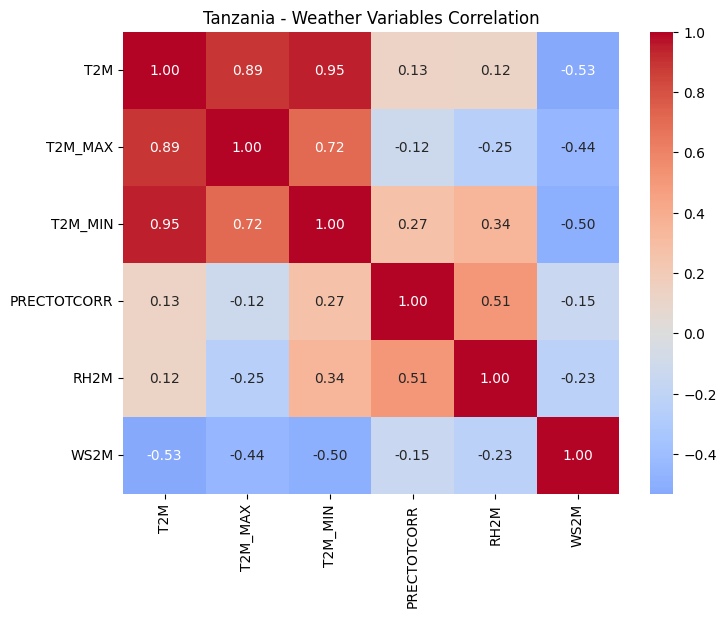

In [7]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Tanzania - Weather Variables Correlation')
plt.show()

### Correlation Heatmap
**What it shows:** Relationships between weather variables

**Key findings:**
- Very strong: T2M vs T2M_MIN (0.95)
- Strong: T2M vs T2M_MAX (0.89)
- Moderate: PRECTOTCORR vs RH2M (0.51)
- Negative: WS2M vs T2M (-0.53)

**Why matters for COP32:**
- Nighttime temperatures drive daily averages
- Rainy days = more humid
- Windy days are cooler

In [8]:
corr_matrix = df[numeric_cols].corr()
print("\nStrongest correlations (|r| > 0.5):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_value:.2f}")


Strongest correlations (|r| > 0.5):
T2M vs T2M_MAX: 0.89
T2M vs T2M_MIN: 0.95
T2M vs WS2M: -0.53
T2M_MAX vs T2M_MIN: 0.72
PRECTOTCORR vs RH2M: 0.51


**Bubble size:**

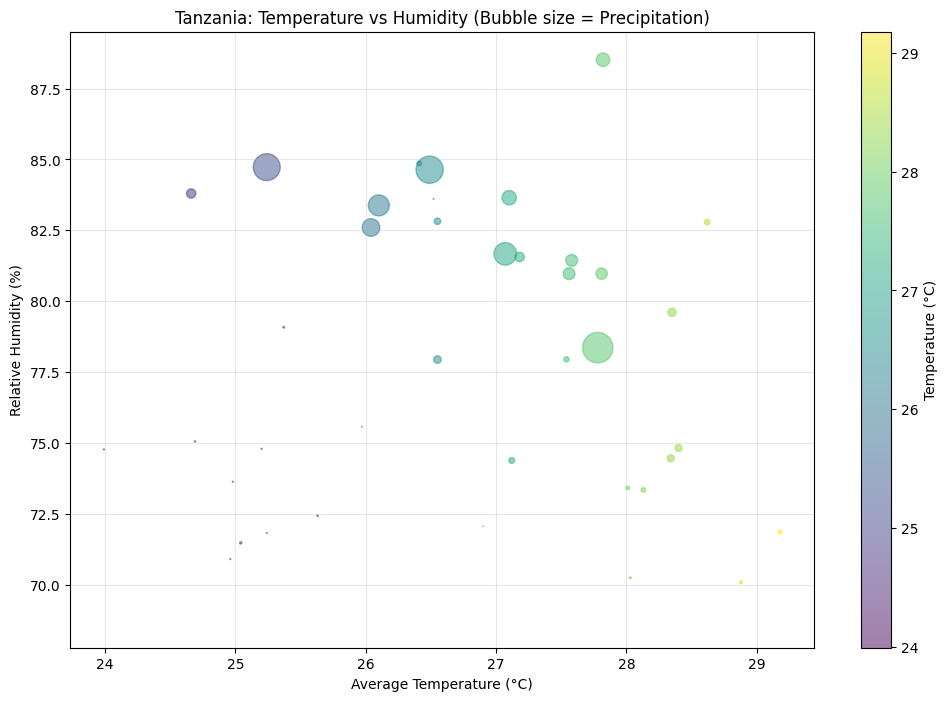

In [9]:
sample = df.iloc[::100, :]
plt.figure(figsize=(12, 8))
scatter = plt.scatter(sample['T2M'], sample['RH2M'], 
                      s=sample['PRECTOTCORR']*10, alpha=0.5, c=sample['T2M'], cmap='viridis')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Tanzania: Temperature vs Humidity (Bubble size = Precipitation)')
plt.grid(True, alpha=0.3)
plt.show()

### Bubble Chart (Temperature vs Humidity, Size = Precipitation)
**What it shows:** Heavy rain occurs at various temperatures

**Key findings:**
- Most bubbles small to medium
- Large bubbles (heavy rain) across temperature range
- Rainfall not strongly tied to temperature

**Why matters for COP32:**
- Flood risk exists year-round
- Cannot predict floods by temperature
- Need constant monitoring

**Daily Precipitation:**

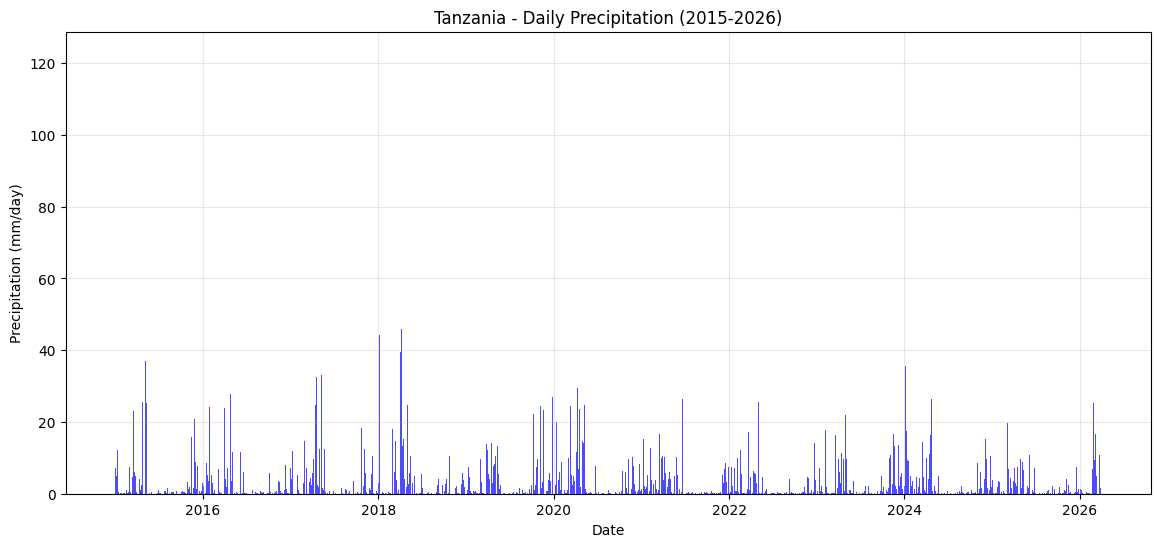

In [10]:
monthly_rain = df.groupby('Date')['PRECTOTCORR'].sum()
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue', alpha=0.7)
plt.title('Tanzania - Daily Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, alpha=0.3)
plt.show()

### Daily Precipitation (Time Series)
**What it shows:** Rainfall patterns 2015-2026

**Key findings:**
- Moderate rainfall (3.74 mm/day average)
- Clear wet and dry seasons visible
- Extreme events up to ~90 mm/day

**Why matters for COP32:**
- Bimodal rainfall pattern (typical of East Africa)
- Shifts in rainy seasons affect food security
- Flood risk exists but less severe than Nigeria

**Temperature vs Humidity:**

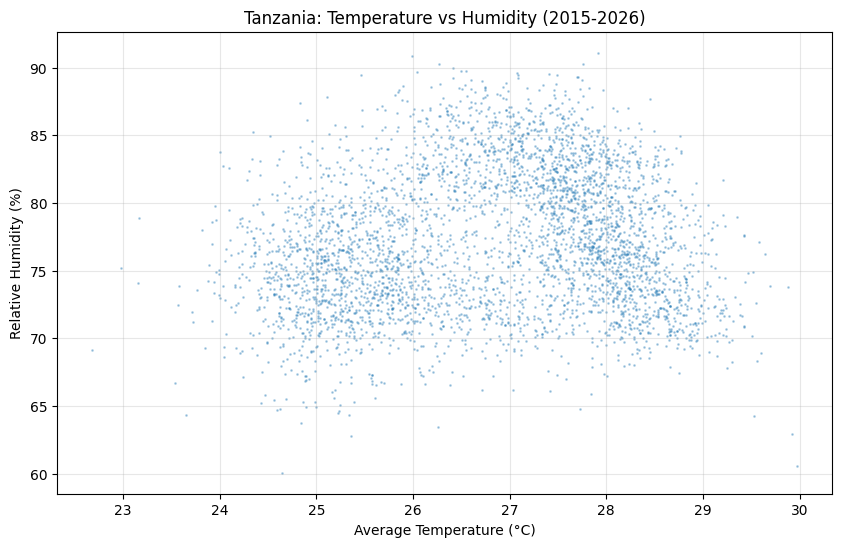

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Tanzania: Temperature vs Humidity (2015-2026)')
plt.grid(True, alpha=0.3)
plt.show()

### Temperature vs Humidity (Scatter Plot)
**What it shows:** Relationship between temperature and humidity

**Key findings:**
- Temperature range: ~20°C to 29°C
- Humidity range: ~50% to 85%
- Weak negative trend (hotter = slightly drier)

**Why matters for COP32:**
- Less extreme than Kenya's heat-dry correlation
- Moderate heat stress conditions
- Health impacts exist but less severe

**Temperature Range vs Wind Speed:**

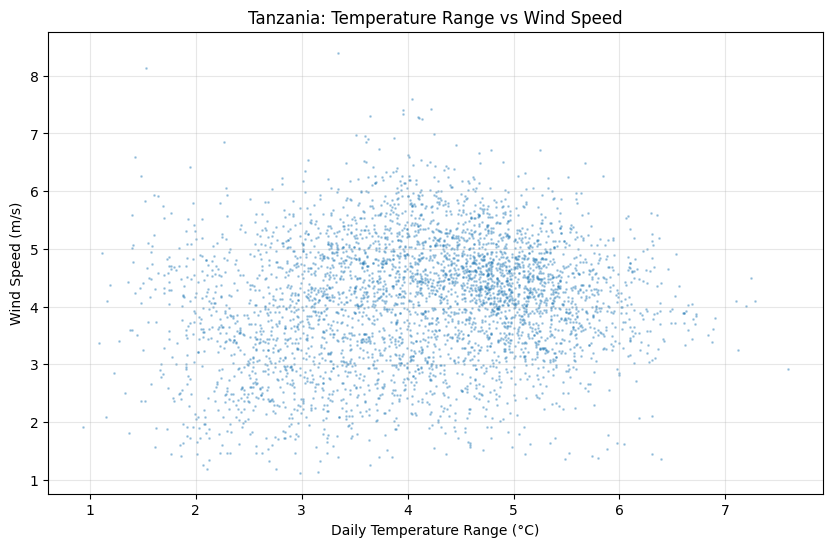

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
plt.xlabel('Daily Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Tanzania: Temperature Range vs Wind Speed')
plt.grid(True, alpha=0.3)
plt.show()

### Temperature Range vs Wind Speed (Scatter Plot)
**What it shows:** Daily temperature fluctuation vs wind

**Key findings:**
- Temperature range: 1°C to 7°C (small compared to Sudan)
- Wind speed: 1 m/s to 7 m/s
- Weak negative correlation

**Why matters for COP32:**
- Stable daily temperatures (small swings)
- Wind not a primary stressor
- Predictable conditions benefit agriculture

**Precipitation Distribution:**

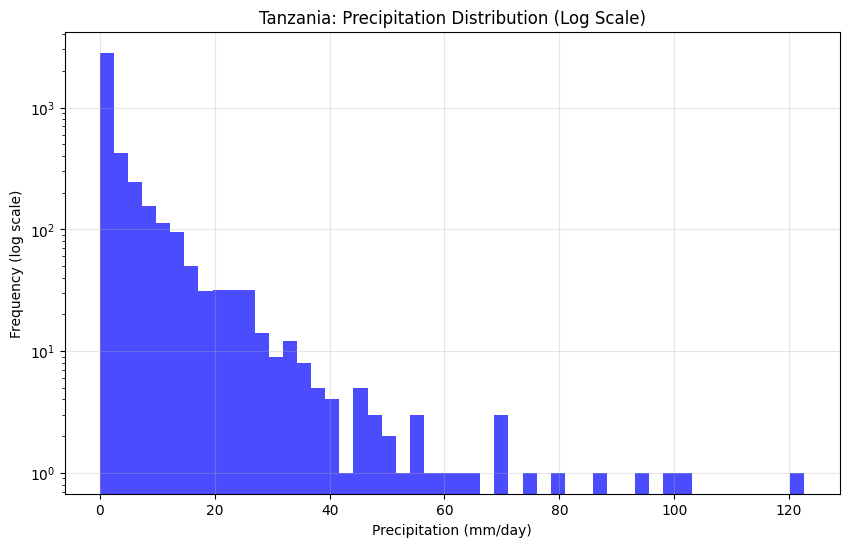

In [13]:
import numpy as np
plt.figure(figsize=(10, 6))
plt.hist(df['PRECTOTCORR'], bins=50, alpha=0.7, color='blue')
plt.yscale('log')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Tanzania: Precipitation Distribution (Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

### Precipitation Distribution (Log Scale Histogram)
**What it shows:** Distribution of daily rainfall amounts

**Key findings:**
- Most days: 0-10 mm
- Long tail of events up to 120 mm
- Skewed distribution typical of East Africa

**Why matters for COP32:**
- Extreme events (120 mm) cause flooding
- Rare but destructive
- Need flood preparedness despite moderate averages

### Conclusion: Tanzania's COP32 Position

**Key Findings:**
- Second hottest country (26.8°C avg) with stable year-round temperatures
- Moderate rainfall (3.74 mm/day) with bipdal pattern
- Small daily temperature swings (1-7°C)
- Extreme rain events up to 120 mm/day cause flooding

**COP32 Asks:**
1. Climate-smart agriculture for bipdal rainfall zones
2. Flood early warning systems for extreme events
3. Heat-health planning for warm conditions
4. Seasonal forecasting for farmers

**Final Statement:**
Tanzania faces moderate but manageable climate stress. Unlike Sudan's extreme heat or Nigeria's massive floods, Tanzania's risk is predictable seasonal variability with occasional extremes. COP32 should focus on supporting seasonal forecasting, flood preparedness, and climate-smart agriculture.